In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA



### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [3]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [4]:
# Create predictor and response variable objects
X = df[feature_names]
y = df['Heating Load']

# Split data to test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Fit scaler to training data
scaler = StandardScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [6]:
# Fit OLS regression
ols = LinearRegression().fit(X_train_scaled, y_train)

# Create preditions
y_pred = ols.predict(X_test_scaled)

mse_ols = mean_squared_error(y_test, y_pred)

print(f'Regression coefficients: {ols.coef_}')
print(f'OLS test MSE: {mse_ols:.3f}')

Regression coefficients: [-6.68692391e+00 -2.89879708e+13  1.44081651e+13  2.96222716e+13
  7.22260734e+00 -3.70502049e-02  2.90147556e+00  8.38940162e-02]
OLS test MSE: 8.880


In [7]:
grader.check("q2")

q2 results:
    q2 - 1 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Expecting nothing
        **********************************************************************
        Line 1, in q2 0
        Failed example:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q2 0[0]>", line 1, in <module>
                assert np.isclose(mse_ols, 8.8395, atol=0.01)
            AssertionError

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [8]:
# Assign lambdas
lambdas = np.logspace(-4,4, 100)

# Create CV of 10
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')

# Fit ridge cv to scaled training data
ridge_cv.fit(X_train_scaled, y_train)

# Show OLS coefficients and ridge coefficients
ridge_cv_ols_coefs = pd.DataFrame({'Feature' : feature_names, 
                   'OLS coefficient': ols.coef_,
                   'Ridge coefficient' : ridge_cv.coef_})

print(f'Best lambda: {ridge_cv.alpha_:.3f}')   # Lambda with the best CV score
ridge_cv_ols_coefs

Best lambda: 0.206


,Feature,OLS coefficient,Ridge coefficient
0,Relative Compactness,-6.686924e+00,-6.352418
1,Surface Area,-2.898797e+13,-3.474392
2,Wall Area,1.440817e+13,0.816587
3,Roof Area,2.962227e+13,-3.797180
4,Overall Height,7.222607e+00,7.306373
5,Orientation,-3.705020e-02,-0.025299
6,Glazing Area,2.901476e+00,2.670852
7,Glazing Area Distribution,8.389402e-02,0.356417


In [9]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

The penalty term is doing its job. This apparent in comparing the OLS coefficients and the Ridge coefficients. The OLS regression has much larger coefficients for surface, wall, and roof area which are closer to 0 in the Ridge regression. This suggests that these coefficients do not have as much impact in the model.

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [10]:
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

print(f'Ridge test MSE: {mse_rcv:.3f}')

Ridge test MSE: 8.844


In [11]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

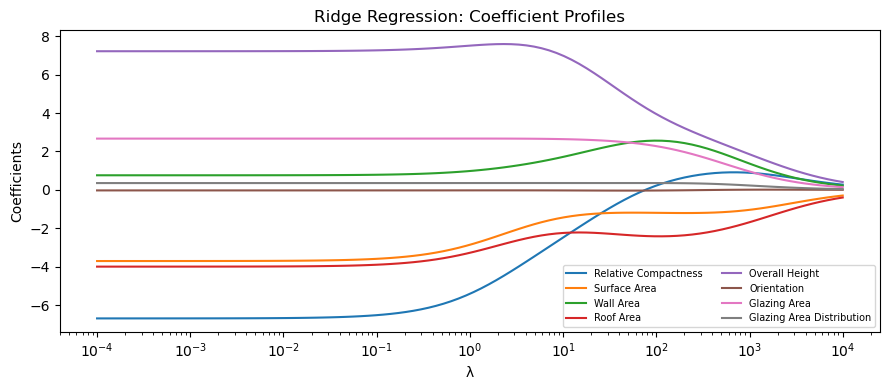

In [12]:
ridge_coefs =  []

for lam in lambdas:
    ridge_model = Ridge(alpha = lam)
    ridge_model.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge_model.coef_)

plt.figure(figsize=(9, 4))
plt.plot(lambdas, ridge_coefs)
plt.xlabel('λ')
plt.xscale('log')
plt.ylabel('Coefficients')
plt.title('Ridge Regression: Coefficient Profiles')
plt.legend(feature_names, loc = "lower right", ncol = 2, fontsize = 7)
plt.tight_layout()
plt.show()

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

According to the coefficient profile, `relative compactness` and `overall height` had the largest absolute values, meaning they appear to be the most important.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [13]:
lasso_cv = LassoCV(alphas = lambdas, cv = 10)

lasso_cv.fit(X_train_scaled, y_train)

ols_lasso_coefs = pd.DataFrame({'Feature' : feature_names, 
                   'OLS Coefficient': ols.coef_,
                   'Lasso Coefficient' : lasso_cv.coef_})
ols_lasso_coefs

,Feature,OLS Coefficient,Lasso Coefficient
0,Relative Compactness,-6.686924e+00,-6.418330
1,Surface Area,-2.898797e+13,-6.231035
2,Wall Area,1.440817e+13,2.152524
3,Roof Area,2.962227e+13,-1.044324
4,Overall Height,7.222607e+00,7.309160
5,Orientation,-3.705020e-02,-0.023593
6,Glazing Area,2.901476e+00,2.670194
7,Glazing Area Distribution,8.389402e-02,0.354971


In [14]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

The lasso model shrank the coefficients to a similar magnitude as the Ridge model, however the `surface area` and `wall area` coefficient was much closer to 0 in the ridge model than the lasso. However, the lasso model shrank `roof area` to a value closer to 0 than the ridge.

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [15]:

y_test_pred_lcv = lasso_cv.predict(X_test_scaled)
mse_lcv = mean_squared_error(y_test_pred_lcv, y_test)

print(f'Lasso CV test MSE: {mse_lcv:.3f}')


Lasso CV test MSE: 8.842


In [16]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [17]:
test_mses = pd.DataFrame({
    'Regression Type' : ["OLS", 'Ridge CV', 'Lasso CV'],
    'Test MSE' : [mse_ols, mse_rcv, mse_lcv]
})

test_mses

,Regression Type,Test MSE
0,OLS,8.880090
1,Ridge CV,8.843961
2,Lasso CV,8.841571


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.924e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

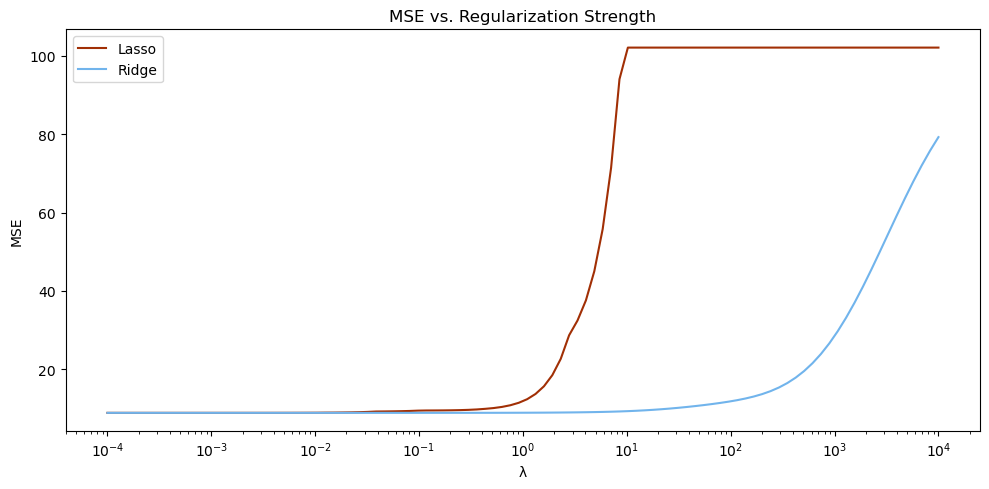

In [18]:

mse_lasso = []
mse_ridge = []
lambdas = np.logspace(-4, 4, 100)  # 100 values from 0.001 to 100

for lam in lambdas:
    lasso = Lasso(alpha=lam)
    ridge = Ridge(alpha=lam)

    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)

    mse_lasso.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    mse_ridge.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    

plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso, label='Lasso', color="#A12F05")
plt.plot(lambdas, mse_ridge, label='Ridge', color="#71B4EC")
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()


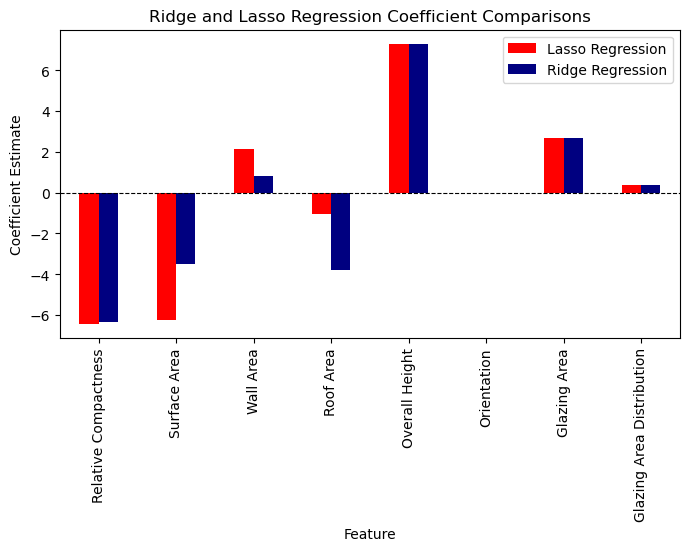

In [19]:
all_coefs = pd.DataFrame({'Lasso Regression' : lasso_cv.coef_,
                   'Ridge Regression' : ridge_cv.coef_},
                   index = feature_names)



fig, axes = plt.subplots(figsize=(8, 4))

axes = all_coefs.plot(color = ['red', "navy"],
                      kind = 'bar',
                      ax = axes)
title = ''
axes.axhline(0, color='black', linewidth=0.8, linestyle='--')
axes.set_ylabel("Coefficient Estimate")
axes.set_xlabel("Feature")
axes.set_title("Ridge and Lasso Regression Coefficient Comparisons")
plt.show()

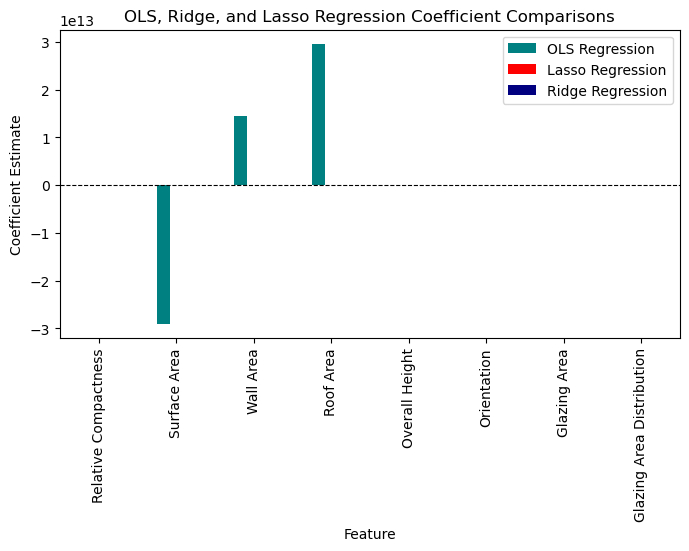

In [20]:
all_coefs = pd.DataFrame({'OLS Regression' : ols.coef_,
                          'Lasso Regression' : lasso_cv.coef_,
                          'Ridge Regression' : ridge_cv.coef_},
                          index = feature_names)



fig, axes = plt.subplots(figsize=(8, 4))

axes = all_coefs.plot(color = ['teal', 'red', 'navy'],
                      kind = 'bar',
                      ax = axes)
title = ''
axes.axhline(0, color='black', linewidth=0.8, linestyle='--')
axes.set_ylabel("Coefficient Estimate")
axes.set_xlabel("Feature")
axes.set_title("OLS, Ridge, and Lasso Regression Coefficient Comparisons")
plt.show()

> **Q4: Which model would you pick for this dataset? Why?**

For this dataset, I would choose a ridge regression. It had the lowest test MSE (with Lasso having a similar but slightly higher MSE), and the seemingly less important features were reduced to a coefficient estimate close to 0. It also maintained the coefficient values of the potentially more important features, `relative compactness` and `overall height`.

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [21]:
pca = PCA(n_components= 8)
pca_full = pca.fit(X_train_scaled)


explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

pca_table = pd.DataFrame({'Component' : list(range(1,9)), 
             'Individual variance ': explained_var,
             'Cumulative variance' : cumulative_var})

pca_table

,Component,Individual variance,Cumulative variance
0,1,4.629048e-01,0.462905
1,2,1.563182e-01,0.619223
2,3,1.497484e-01,0.768971
3,4,1.243148e-01,0.893286
4,5,9.966322e-02,0.992949
5,6,6.477268e-03,0.999427
6,7,5.733790e-04,1.000000
7,8,2.730130e-32,1.000000


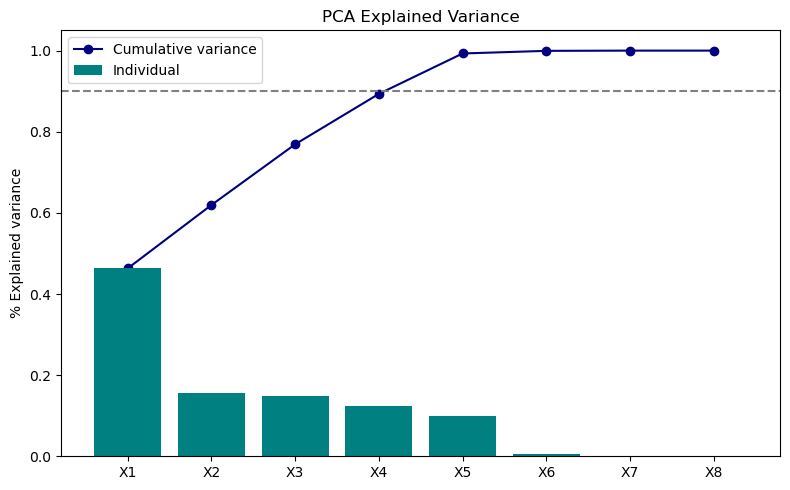

In [22]:
components = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(components, explained_var, color="teal", zorder = 2, label = "Individual")

ax.plot(components, cumulative_var, color = "navy", marker = 'o', zorder = 1, label = "Cumulative variance")
ax.set_ylabel('% Explained variance')
ax.set_title('PCA Explained Variance')
ax.axhline(0.9, color = "gray", linestyle = '--')

ax.legend()
plt.tight_layout()
plt.show()


In [23]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

It takes 5 components to reach at least 90% of the variance explained.

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [24]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above
best_k = 5

pca_final = PCA(n_components=5)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

ols_pcr = LinearRegression()
ols_pcr.fit(X_train_pca, y_train)

y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)


print(f'PCR MSE: {mse_pcr:.3f}')

PCR MSE: 12.703


<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

I chose 5 for k, because 5 PC explains over 90% of the variance.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [25]:
all_mse_results = pd.DataFrame({ 'Model' : ['OLS', 'Ridge', 'Lasso', 'PCR'],
                  'Tuning Parameter' : ['None', ridge_cv.alpha_, lasso_cv.alpha_, best_k],
                   'Test MSE': [mse_ols, mse_rcv, mse_lcv, mse_pcr]
                   })

all_mse_results

,Model,Tuning Parameter,Test MSE
0,OLS,None,8.880090
1,Ridge,0.205651,8.843961
2,Lasso,0.00163,8.841571
3,PCR,5,12.703310


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

Based on the table, the Lasso model performs the best, having the lowest MSE. However, all four models perform relatively similar to each other. Based on the MSE of 12.7, the assumptions for PCR do not hold.

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [26]:
grader.check_all()

q1 results: All test cases passed!

q2 results:
    q2 - 1 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Expecting nothing
        **********************************************************************
        Line 1, in q2 0
        Failed example:
            assert np.isclose(mse_ols, 8.8395, atol=0.01)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q2 0[0]>", line 1, in <module>
                assert np.isclose(mse_ols, 8.8395, atol=0.01)
            AssertionError

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!